# Evolução dos Preços dos Imóveis — Joinville

Evolução **mês a mês** a partir dos dados limpos (`joinville_imoveis_limpo_2026-*.parquet`):
1. visão **geral**, 2. **por tipo de imóvel**, 3. **por bairro**,
4. **m² dos imóveis novos por mês de publicação** (coorte de oferta).
Métrica principal: **mediana de `preco_por_m2`** (robusta a outliers).

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

CIDADE = "joinville"
PASTA_DADOS = Path("../dados") / CIDADE
ARQUIVOS = sorted(PASTA_DADOS.glob(f"{CIDADE}_imoveis_limpo_*.parquet"))

print(f"{len(ARQUIVOS)} arquivos encontrados:")
for a in ARQUIVOS:
    print(" -", a.name)

7 arquivos encontrados:
 - joinville_imoveis_limpo_2026-04.parquet
 - joinville_imoveis_limpo_2026-05.parquet
 - joinville_imoveis_limpo_2026-06.parquet
 - joinville_imoveis_limpo_2026-07.parquet
 - joinville_imoveis_limpo_2026-08.parquet
 - joinville_imoveis_limpo_2026-09.parquet
 - joinville_imoveis_limpo_2026-10.parquet


In [2]:
COLS = ["url", "valor_imovel", "preco_por_m2", "tipo_imovel", "bairro", "metragem",
        "fonte", "data_criacao", "dias_publicacao"]

dfs = []
for arq in ARQUIVOS:
    mes = re.search(r"(\d{4}-\d{2})", arq.stem).group(1)
    df = pd.read_parquet(arq, columns=COLS)
    df["mes"] = mes
    dfs.append(df)

base = pd.concat(dfs, ignore_index=True)

# Higiene: infinitos (metragem 0) -> NaN; bairros 'none'/'nan'/vazio -> 's/b'
base["preco_por_m2"] = base["preco_por_m2"].replace([np.inf, -np.inf], np.nan)
base["bairro"] = base["bairro"].astype(str).str.strip()
base.loc[base["bairro"].str.lower().isin(["none", "nan", ""]), "bairro"] = "s/b"
base = base.dropna(subset=["preco_por_m2", "valor_imovel"]).reset_index(drop=True)

# Outliers (todas as análises herdam): fora de [0.5%, 99.5%] globais de
# preco_por_m2 e valor_imovel (pool dos 7 meses)
_f = base[np.isfinite(base["preco_por_m2"]) & (base["preco_por_m2"] > 0)
           & base["valor_imovel"].notna() & (base["valor_imovel"] > 0)]
lo_m2, hi_m2 = _f["preco_por_m2"].quantile([0.005, 0.995])
lo_v, hi_v = _f["valor_imovel"].quantile([0.005, 0.995])
print(f"cortes m²: [{lo_m2:.0f}, {hi_m2:.0f}]  valor: [{lo_v:.0f}, {hi_v:.0f}]")
print(f"removidos: {len(_f) - len(_f[(_f['preco_por_m2'].between(lo_m2, hi_m2)) & (_f['valor_imovel'].between(lo_v, hi_v))])}")
base = _f[(_f["preco_por_m2"].between(lo_m2, hi_m2))
           & (_f["valor_imovel"].between(lo_v, hi_v))].reset_index(drop=True)

print(base.shape)
print(base.groupby("mes").size().rename("n_anuncios"))

cortes m²: [56, 19760]  valor: [166437, 9500000]
removidos: 3458
(181550, 10)
mes
2026-04    33876
2026-05    26300
2026-06    23756
2026-07    22699
2026-08    24744
2026-09    23802
2026-10    26373
Name: n_anuncios, dtype: int64


## 1. Evolução geral (todos os imóveis)

,mes,n,p50_m2,media_m2,p50_valor,mom_p50_m2_%,mom_p50_valor_%
0,2026-04,33876,6338.03,6652.04,735000.0,NaN,NaN
1,2026-05,26300,6190.48,6486.98,750000.0,-2.33,2.04
2,2026-06,23756,6250.00,6535.60,750000.0,0.96,0.00
3,2026-07,22699,6310.16,6620.96,764550.0,0.96,1.94
4,2026-08,24744,6296.30,6566.21,780000.0,-0.22,2.02
5,2026-09,23802,6681.80,7081.00,747712.0,6.12,-4.14
6,2026-10,26373,6521.74,6822.49,769000.0,-2.40,2.85


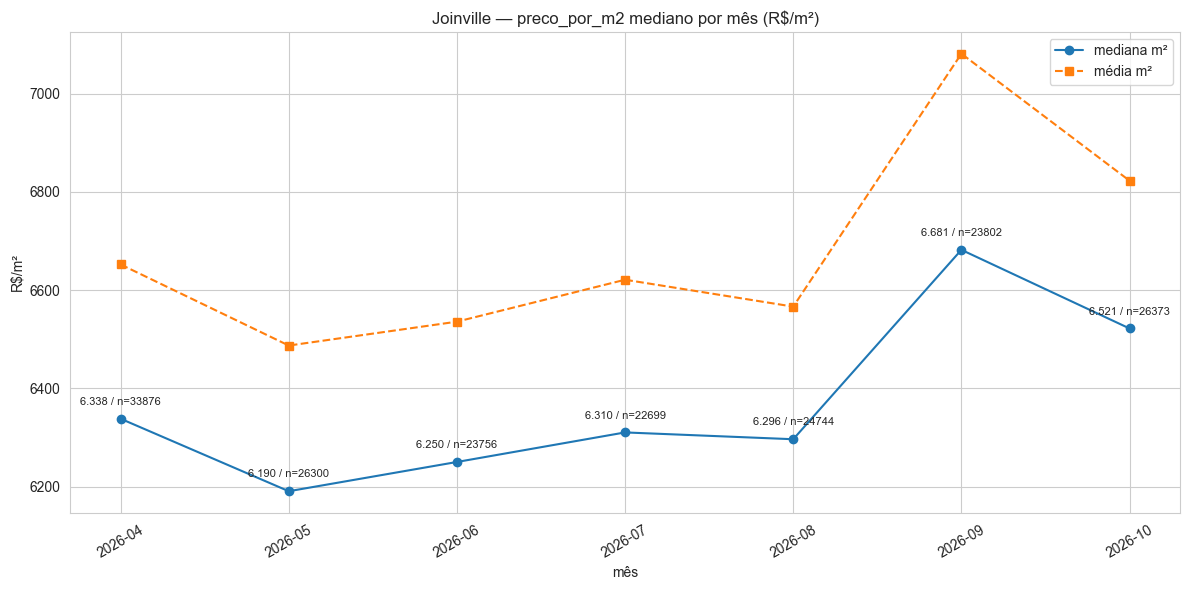

In [3]:
geral = (
    base.groupby("mes")
    .agg(n=("preco_por_m2", "size"),
         p50_m2=("preco_por_m2", "median"),
         media_m2=("preco_por_m2", "mean"),
         p50_valor=("valor_imovel", "median"))
    .reset_index()
)
geral["mom_p50_m2_%"] = geral["p50_m2"].pct_change() * 100
geral["mom_p50_valor_%"] = geral["p50_valor"].pct_change() * 100
display(geral.round(2))

fig, ax = plt.subplots()
ax.plot(geral["mes"], geral["p50_m2"], marker="o", label="mediana m²")
ax.plot(geral["mes"], geral["media_m2"], marker="s", linestyle="--", label="média m²")
for x, y, n in zip(geral["mes"], geral["p50_m2"], geral["n"]):
    ax.annotate(f"{int(y):,} / n={n}".replace(",", "."), (x, y),
                textcoords="offset points", xytext=(0, 10), ha="center", fontsize=8)
ax.set_title("Joinville — preco_por_m2 mediano por mês (R$/m²)")
ax.set_xlabel("mês")
ax.set_ylabel("R$/m²")
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 2. Evolução por tipo de imóvel

tipo_imovel,apartamento,casa,comercial,galpao,outros,predio_inteiro,rural,terreno
mes,,,,,,,,
2026-04,7931.0,5545.0,6579.0,3959.0,8492.0,4619.0,4091.0,1063.0
2026-05,7780.0,5541.0,5804.0,3666.0,8487.0,4839.0,392.0,1054.0
2026-06,7910.0,5612.0,6931.0,4106.0,8119.0,4508.0,3819.0,1065.0
2026-07,7927.0,5616.0,6667.0,4193.0,9044.0,8612.0,5000.0,1072.0
2026-08,7834.0,5600.0,6850.0,4167.0,8773.0,4508.0,1400.0,1069.0
2026-09,8182.0,5774.0,6571.0,3533.0,6903.0,7356.0,6909.0,1062.0
2026-10,8283.0,5745.0,6923.0,3533.0,5014.0,NaN,6789.0,1236.0


C:\Users\jefer\AppData\Local\Temp\ipykernel_18472\1984113580.py:11: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  display((tipo_m2.pct_change() * 100).round(2).rename(columns=lambda c: c + " MoM %"))


tipo_imovel,apartamento MoM %,casa MoM %,comercial MoM %,galpao MoM %,outros MoM %,predio_inteiro MoM %,rural MoM %,terreno MoM %
mes,,,,,,,,
2026-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05,-1.90,-0.09,-11.78,-7.40,-0.05,4.75,-90.42,-0.84
2026-06,1.67,1.29,19.42,12.01,-4.34,-6.83,874.82,1.04
2026-07,0.22,0.07,-3.81,2.12,11.39,91.02,30.93,0.66
2026-08,-1.17,-0.29,2.75,-0.63,-3.00,-47.65,-72.00,-0.27
2026-09,4.44,3.11,-4.07,-15.22,-21.31,63.16,393.51,-0.60
2026-10,1.24,-0.50,5.35,0.00,-27.36,0.00,-1.75,16.29


tipo_imovel,apartamento,casa,comercial,galpao,outros,predio_inteiro,rural,terreno
mes,,,,,,,,
2026-04,15989.0,14461.0,289.0,100.0,396.0,43.0,238.0,2360.0
2026-05,11605.0,11670.0,206.0,87.0,389.0,29.0,162.0,2152.0
2026-06,10640.0,10415.0,257.0,88.0,116.0,35.0,190.0,2015.0
2026-07,10197.0,10293.0,197.0,64.0,209.0,2.0,111.0,1626.0
2026-08,11256.0,10844.0,227.0,79.0,260.0,23.0,141.0,1914.0
2026-09,11734.0,10315.0,447.0,47.0,14.0,4.0,112.0,1129.0
2026-10,11956.0,11578.0,245.0,81.0,3.0,NaN,156.0,2354.0


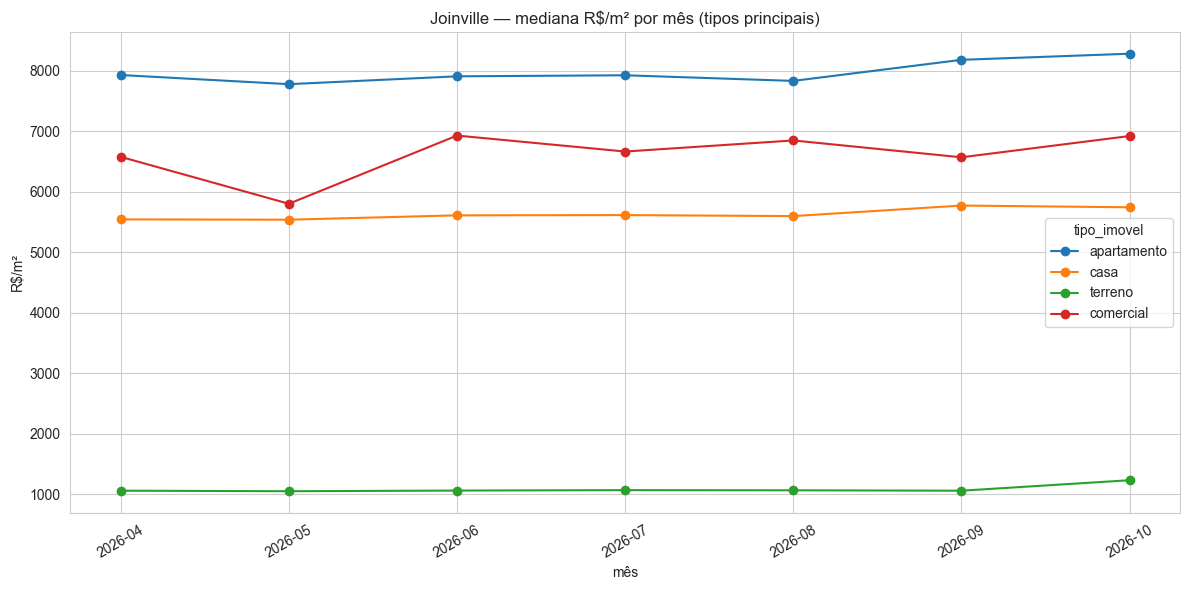

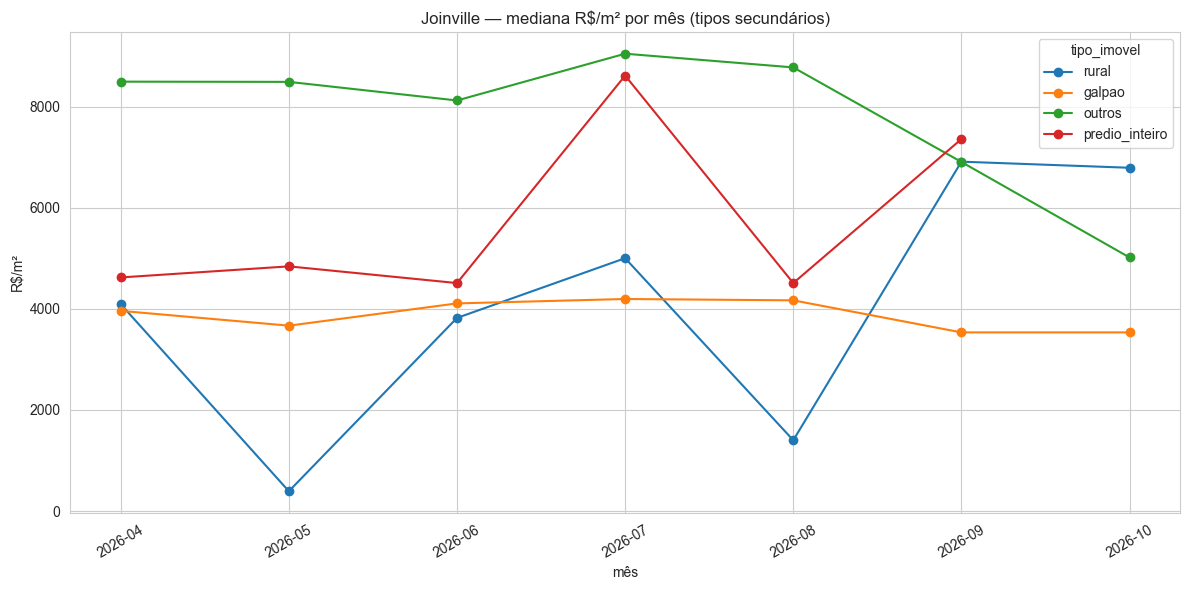

In [4]:
TIPOS_PRINCIPAIS = ["apartamento", "casa", "terreno", "comercial"]
TIPOS_SECUNDARIOS = ["rural", "galpao", "outros", "predio_inteiro"]

tipo_m2 = (
    base.groupby(["mes", "tipo_imovel"])["preco_por_m2"]
    .median()
    .unstack("tipo_imovel")
)
display(tipo_m2.round(0))

display((tipo_m2.pct_change() * 100).round(2).rename(columns=lambda c: c + " MoM %"))

# N mensal por tipo (para sinalizar tipos com amostra pequena)
display(base.groupby(["mes", "tipo_imovel"]).size().unstack("tipo_imovel"))

# Gráfico A — tipos principais
ax = tipo_m2[TIPOS_PRINCIPAIS].plot(marker="o", figsize=(12, 6))
ax.set_title("Joinville — mediana R$/m² por mês (tipos principais)")
ax.set_xlabel("mês")
ax.set_ylabel("R$/m²")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Gráfico B — tipos secundários em eixo próprio (escalas muito diferentes dos
# principais; predio_inteiro tem ~23 anúncios/mês — mediana mais ruidosa)
ax = tipo_m2[TIPOS_SECUNDARIOS].plot(marker="o", figsize=(12, 6))
ax.set_title("Joinville — mediana R$/m² por mês (tipos secundários)")
ax.set_xlabel("mês")
ax.set_ylabel("R$/m²")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 3. Evolução por bairro

40 bairros (mediana 2026-10, N>=50), do mais caro ao mais barato


,med_m2_ref,n_ref
bairro,,
atiradores,9861.0,1237
centro,9688.0,1008
america,9668.0,3049
anita garibaldi,8586.0,2357
santo antonio,7987.0,1247
gloria,7611.0,1639
saguacu,7258.0,1924
bucarein,6439.0,506
costa e silva,6374.0,1998


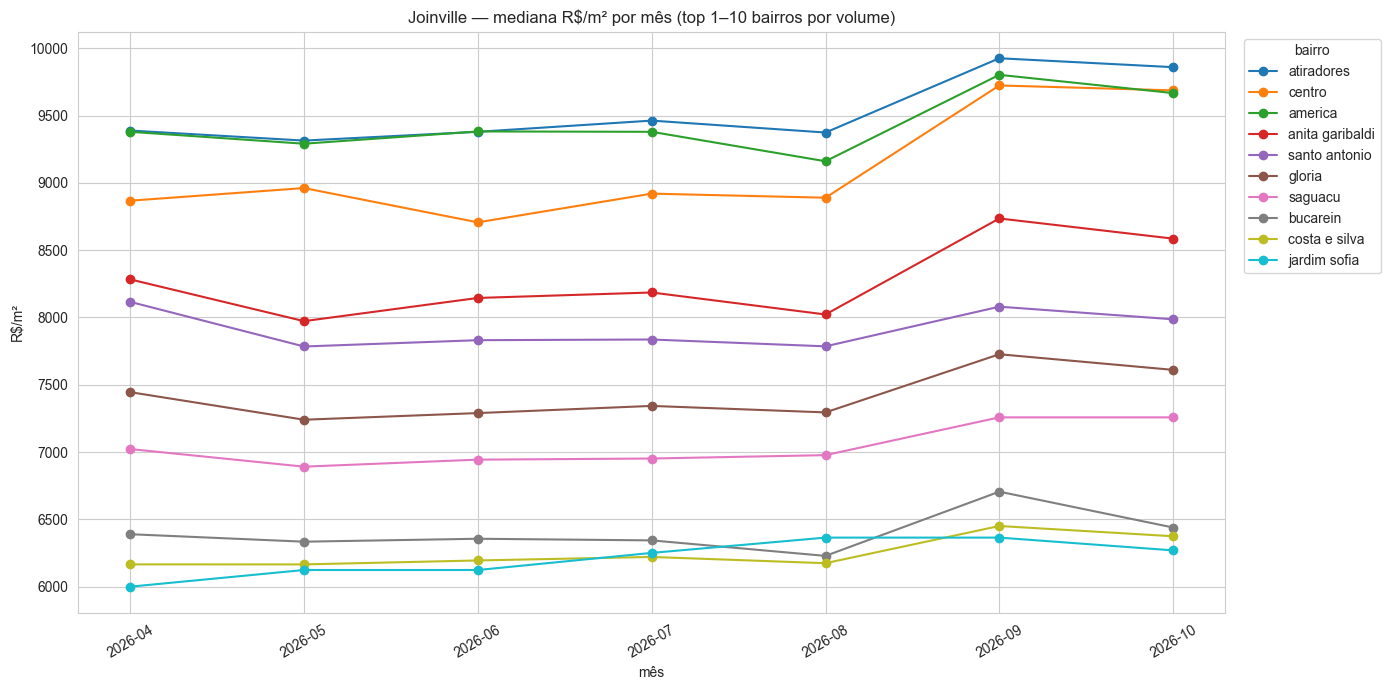

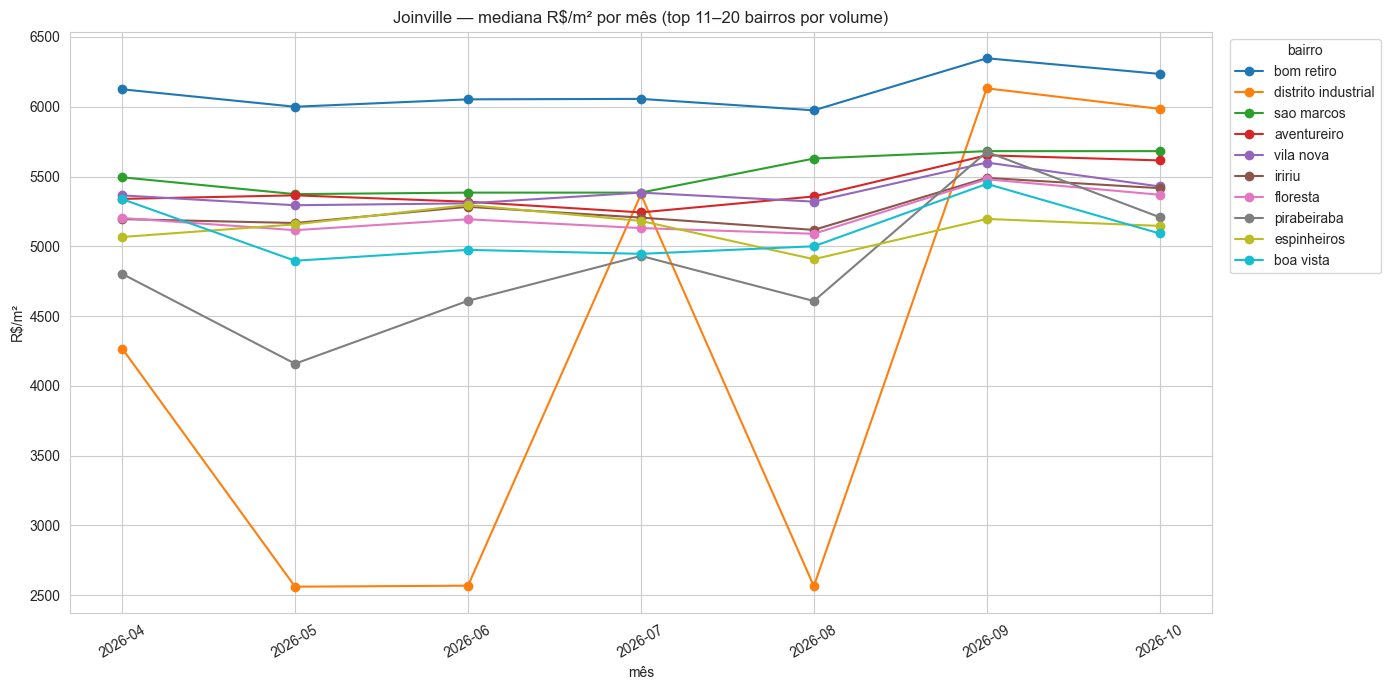

In [5]:
MIN_ANUNCIOS_MES = 30  # bairros com menos que isso num mês são ocultados só no gráfico
LIXO = ["s/b", "none", "nan", "s/n", "100", "418", "n12 bairro gloria"]
MES_REF = "2026-10"  # ranking pelo preço do mês mais recente
MIN_N_REF = 50  # bairros com menos anúncios no mês-ref têm mediana instável

ref = (base[(base["mes"] == MES_REF)
            & (~base["bairro"].str.lower().isin(LIXO))]
       .groupby("bairro")["preco_por_m2"].agg(["median", "count"]))
ref = ref[ref["count"] >= MIN_N_REF].sort_values("median", ascending=False)
print(f"{len(ref)} bairros (mediana {MES_REF}, N>={MIN_N_REF}), do mais caro ao mais barato")
display(ref.round(0).rename(columns={"median": "med_m2_ref", "count": "n_ref"}))

TOP10, NEXT10 = ref.head(10).index.tolist(), ref.iloc[10:20].index.tolist()
bairro_m2 = (
    base[base["bairro"].isin(TOP10 + NEXT10)]
    .groupby(["mes", "bairro"])["preco_por_m2"]
    .agg(["median", "size"])
)
med = bairro_m2["median"].unstack("bairro")
n = bairro_m2["size"].unstack("bairro")
med = med.where(n >= MIN_ANUNCIOS_MES)

# Gráfico A — top 1–10
ax = med[TOP10].plot(marker="o", figsize=(14, 7))
ax.set_title("Joinville — mediana R$/m² por mês (top 1–10 bairros por volume)")
ax.set_xlabel("mês")
ax.set_ylabel("R$/m²")
ax.legend(title="bairro", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Gráfico B — top 11–20
ax = med[NEXT10].plot(marker="o", figsize=(14, 7))
ax.set_title("Joinville — mediana R$/m² por mês (top 11–20 bairros por volume)")
ax.set_xlabel("mês")
ax.set_ylabel("R$/m²")
ax.legend(title="bairro", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [6]:
# Tabela completa por bairro: mediana no 1º e último mês + variação no período
pivot = (
    base.groupby(["mes", "bairro"])["preco_por_m2"]
    .median()
    .unstack("mes")
)
primeiro, ultimo = pivot.columns[0], pivot.columns[-1]
resumo_bairro = pd.DataFrame({
    "n_total": base.groupby("bairro").size(),
    f"p50_{primeiro}": pivot[primeiro].round(0),
    f"p50_{ultimo}": pivot[ultimo].round(0),
})
resumo_bairro["variacao_periodo_%"] = (
    (resumo_bairro[f"p50_{ultimo}"] - resumo_bairro[f"p50_{primeiro}"])
    / resumo_bairro[f"p50_{primeiro}"] * 100
).round(2)
resumo_bairro = resumo_bairro.sort_values("variacao_periodo_%", ascending=False)

print("=== Maiores valorizações ===")
display(resumo_bairro.head(10))
print("=== Maiores quedas ===")
display(resumo_bairro.tail(10))

=== Maiores valorizações ===


,n_total,p50_2026-04,p50_2026-10,variacao_periodo_%
bairro,,,,
distrito industrial,500,4267.0,5985.0,40.26
area rural,43,5333.0,6213.0,16.50
centro,6573,8868.0,9688.0,9.25
pirabeiraba,3647,4802.0,5208.0,8.45
aventureiro,3758,5340.0,5615.0,5.15
atiradores,8476,9390.0,9861.0,5.02
jardim sofia,1731,5999.0,6269.0,4.50
iririu,5648,5195.0,5416.0,4.25
santa catarina,1609,4718.0,4914.0,4.15


=== Maiores quedas ===


,n_total,p50_2026-04,p50_2026-10,variacao_periodo_%
bairro,,,,
vila cubatao,55,3709.0,3050.0,-17.77
rio bonito,293,874.0,484.0,-44.62
profipo,304,3771.0,1414.0,-62.50
100,1,NaN,NaN,NaN
418,1,NaN,NaN,NaN
quiriri,4,6354.0,NaN,NaN
s/b,29,4550.0,NaN,NaN
s/n,2,NaN,NaN,NaN
ulisses guimaraes,16,NaN,5188.0,NaN


## 4. M² dos imóveis novos por mês de publicação (coorte de oferta)

Duas leituras complementares do preço de quem **está entrando** no mercado:
- **A — coorte por `data_criacao`**: precisa, mas cobre só zap/vivareal/imovelweb (~39% da base; chave_mao e olx não trazem a data).
- **B — entrantes por snapshot**: URL (sem query string) vista pela 1ª vez; cobre 100%, mas mistura republicações com anúncios de fato novos.
Mediana (linha sólida) e média (tracejada) em ambas.

,n,med_m2,media_m2
mes_pub,,,
2015-04,1,4450.0,4450.0
2016-01,1,7564.0,7564.0
2016-07,4,6579.0,6579.0
2016-09,2,2105.0,2105.0
2016-10,3,613.0,681.0
...,...,...,...
2026-06,2315,5893.0,6135.0
2026-07,2434,6349.0,6694.0
2026-08,3294,5844.0,5947.0


fonte,imovelweb,viva_real,zap_imoveis
mes_pub,,,
2015-04,1.00,NaN,NaN
2016-01,1.00,NaN,NaN
2016-07,NaN,0.25,0.75
2016-09,1.00,NaN,NaN
2016-10,NaN,0.67,0.33
...,...,...,...
2026-06,0.06,0.25,0.69
2026-07,0.13,0.28,0.59
2026-08,0.07,0.58,0.35


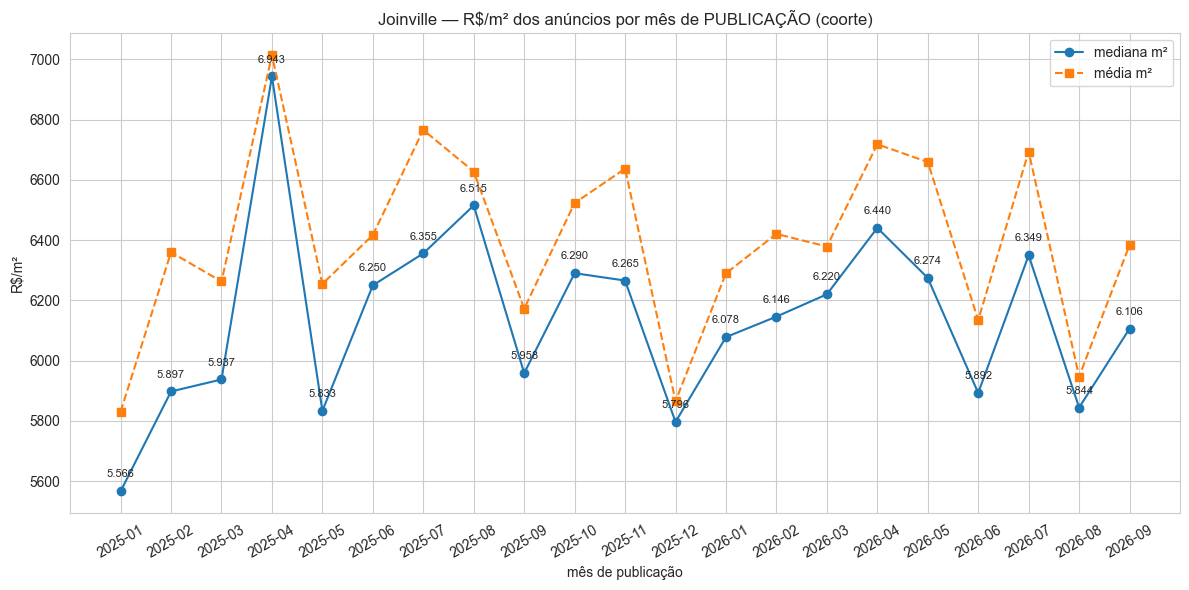

In [7]:
# Método A — coorte por data de publicação do anúncio
pub = (
    base.drop_duplicates(subset="url")
    .loc[lambda d: d["data_criacao"].notna()]
    .copy()
)
pub["data_criacao"] = pd.to_datetime(pub["data_criacao"], format="%d/%m/%Y", errors="coerce")
pub = pub.dropna(subset=["data_criacao"])
pub["mes_pub"] = pub["data_criacao"].dt.to_period("M").astype(str)

coorte = (
    pub.groupby("mes_pub")
    .agg(n=("preco_por_m2", "size"),
         med_m2=("preco_por_m2", "median"),
         media_m2=("preco_por_m2", "mean"))
)
display(coorte.round(0))

# Viés de fonte: quem compõe cada coorte
cobertura = pub.groupby("mes_pub")["fonte"].value_counts(normalize=True).unstack().round(2)
display(cobertura)

# Recorte: coortes antigas têm n minúsculo (ruído) e 2026-10 está incompleto
# (snapshot do dia 05); a média é sensível a outliers de m²
coorte_r = coorte[(coorte.index >= "2025-01") & (coorte.index <= "2026-09")]

fig, ax = plt.subplots()
ax.plot(coorte_r.index, coorte_r["med_m2"], marker="o", label="mediana m²")
ax.plot(coorte_r.index, coorte_r["media_m2"], marker="s", linestyle="--", label="média m²")
for x, y, n in zip(coorte_r.index, coorte_r["med_m2"], coorte_r["n"]):
    ax.annotate(f"{int(y):,}".replace(",", "."), (x, y),
                textcoords="offset points", xytext=(0, 10), ha="center", fontsize=8)
ax.set_title("Joinville — R$/m² dos anúncios por mês de PUBLICAÇÃO (coorte)")
ax.set_xlabel("mês de publicação")
ax.set_ylabel("R$/m²")
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

,mes,n_entr,med_entr,media_entr,med_est,media_est
0,2026-04,NaN,NaN,NaN,6338.0,6652.0
1,2026-05,6077.0,6091.0,6403.0,6190.0,6487.0
2,2026-06,8239.0,6309.0,6693.0,6250.0,6536.0
3,2026-07,4572.0,6093.0,6305.0,6310.0,6621.0
4,2026-08,8277.0,6190.0,6534.0,6296.0,6566.0
5,2026-09,12210.0,6400.0,6754.0,6682.0,7081.0
6,2026-10,12767.0,6219.0,6474.0,6522.0,6822.0


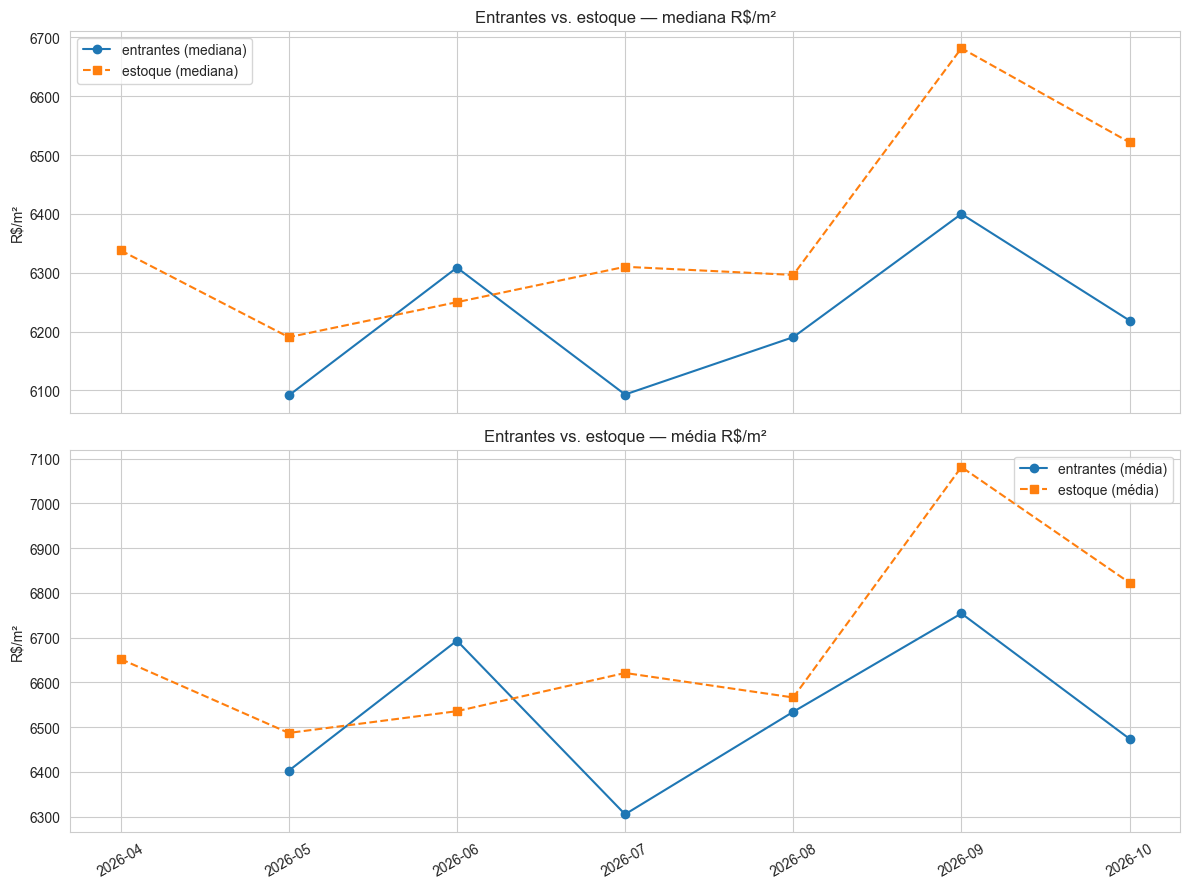

In [8]:
# Método B — entrantes: URL (sem query string) nunca vista nos meses anteriores
b2 = base.copy()
b2["url_norm"] = b2["url"].str.split("?").str[0]

vistos, linhas = set(), []
for mes, g in b2.sort_values("mes").groupby("mes"):
    urls = set(g["url_norm"])
    entr = g[g["url_norm"].isin(urls - vistos)]
    linhas.append({"mes": mes, "n_entr": len(entr),
                    "med_entr": entr["preco_por_m2"].median(),
                    "media_entr": entr["preco_por_m2"].mean()})
    vistos |= urls

entrantes = pd.DataFrame(linhas)
# O 1º snapshot é baseline (sem histórico): tudo é 'entrante' por construção
entrantes.loc[0, ["n_entr", "med_entr", "media_entr"]] = np.nan
estoque = (base.groupby("mes")
           .agg(med_est=("preco_por_m2", "median"),
                media_est=("preco_por_m2", "mean"))
           .reset_index())
comp = entrantes.merge(estoque, on="mes")
display(comp.round(0))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
ax1.plot(comp["mes"], comp["med_entr"], marker="o", label="entrantes (mediana)")
ax1.plot(comp["mes"], comp["med_est"], marker="s", linestyle="--", label="estoque (mediana)")
ax1.set_title("Entrantes vs. estoque — mediana R$/m²")
ax1.legend()
ax1.set_ylabel("R$/m²")
ax2.plot(comp["mes"], comp["media_entr"], marker="o", label="entrantes (média)")
ax2.plot(comp["mes"], comp["media_est"], marker="s", linestyle="--", label="estoque (média)")
ax2.set_title("Entrantes vs. estoque — média R$/m²")
ax2.legend()
ax2.set_ylabel("R$/m²")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [9]:
# Confronto A x B + abertura por tipo de imóvel
print("Método A (coorte data_criacao) x Método B (entrantes) — mediana R$/m²")
display(coorte_r[["med_m2", "n"]].rename(columns={"med_m2": "A_coorte", "n": "n_A"})
        .join(comp.set_index("mes")[["med_entr", "n_entr"]]
              .rename(columns={"med_entr": "B_entrantes", "n_entr": "n_B"}),
              how="inner").round(0))

TIPOS_FOCO = ["apartamento", "casa", "terreno"]
print("Método A por tipo (mediana R$/m² por mês de publicação):")
display(pub[pub["tipo_imovel"].isin(TIPOS_FOCO)]
        .groupby(["mes_pub", "tipo_imovel"])["preco_por_m2"].median()
        .unstack("tipo_imovel").round(0))

Método A (coorte data_criacao) x Método B (entrantes) — mediana R$/m²


,A_coorte,n_A,B_entrantes,n_B
2026-04,6441.0,4069,NaN,NaN
2026-05,6275.0,2143,6091.0,6077.0
2026-06,5893.0,2315,6309.0,8239.0
2026-07,6349.0,2434,6093.0,4572.0
2026-08,5844.0,3294,6190.0,8277.0
2026-09,6106.0,2541,6400.0,12210.0


Método A por tipo (mediana R$/m² por mês de publicação):


tipo_imovel,apartamento,casa,terreno
mes_pub,,,
2015-04,NaN,4450.0,NaN
2016-01,7564.0,NaN,NaN
2016-07,NaN,6579.0,NaN
2016-09,NaN,2105.0,NaN
2016-10,NaN,NaN,613.0
...,...,...,...
2026-06,7130.0,5447.0,1055.0
2026-07,7525.0,5651.0,946.0
2026-08,7333.0,5455.0,940.0


## 5. M² dos novos por mês de publicação — por tipo e por bairro

A coorte do Método A (`data_criacao`) aberta por tipo de imóvel e por bairro.
Recorte 2026-04–2026-09 (2026-10 incompleto); pontos com N<20 são ocultados
nos gráficos. Cobertura: só zap/vivareal/imovelweb trazem `data_criacao` (~39%).

tipo_imovel,apartamento,casa,comercial,terreno
mes_pub,,,,
2026-04,7968.0,5607.0,8891.0,1001.0
2026-05,7528.0,5714.0,8095.0,879.0
2026-06,7130.0,5447.0,6846.0,1055.0
2026-07,7525.0,5651.0,5170.0,946.0
2026-08,7333.0,5455.0,6720.0,940.0
2026-09,7900.0,5467.0,5393.0,960.0


tipo_imovel,apartamento,casa,comercial,terreno
mes_pub,,,,
2026-04,2103,1462,44,400
2026-05,1061,915,21,130
2026-06,995,1083,24,189
2026-07,1205,1018,28,165
2026-08,1218,1566,117,349
2026-09,1107,1116,25,266


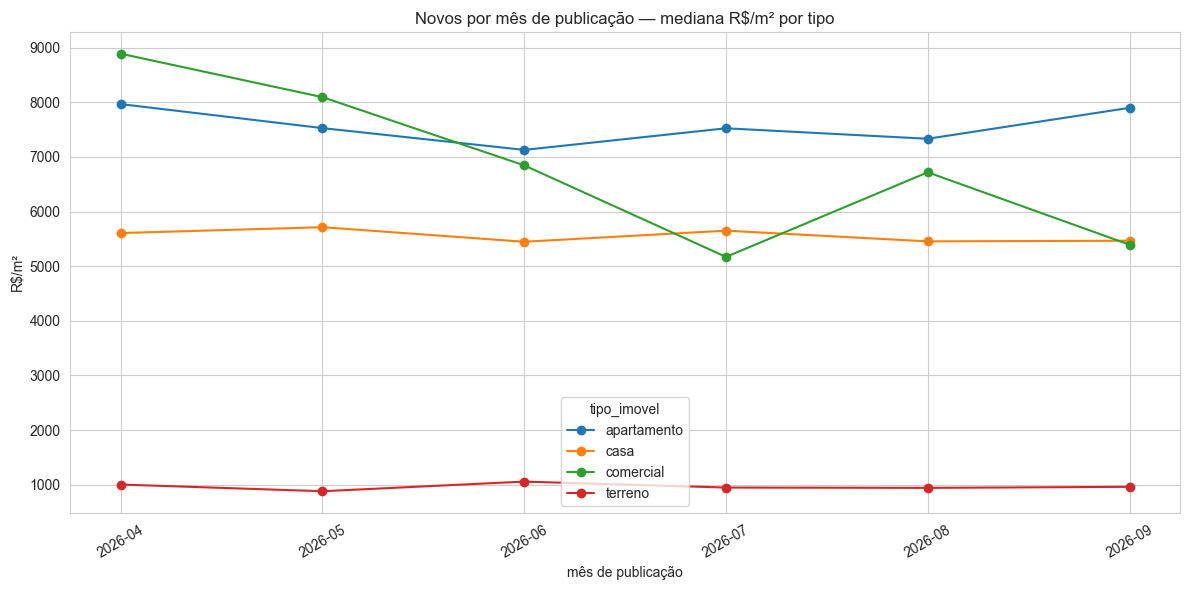

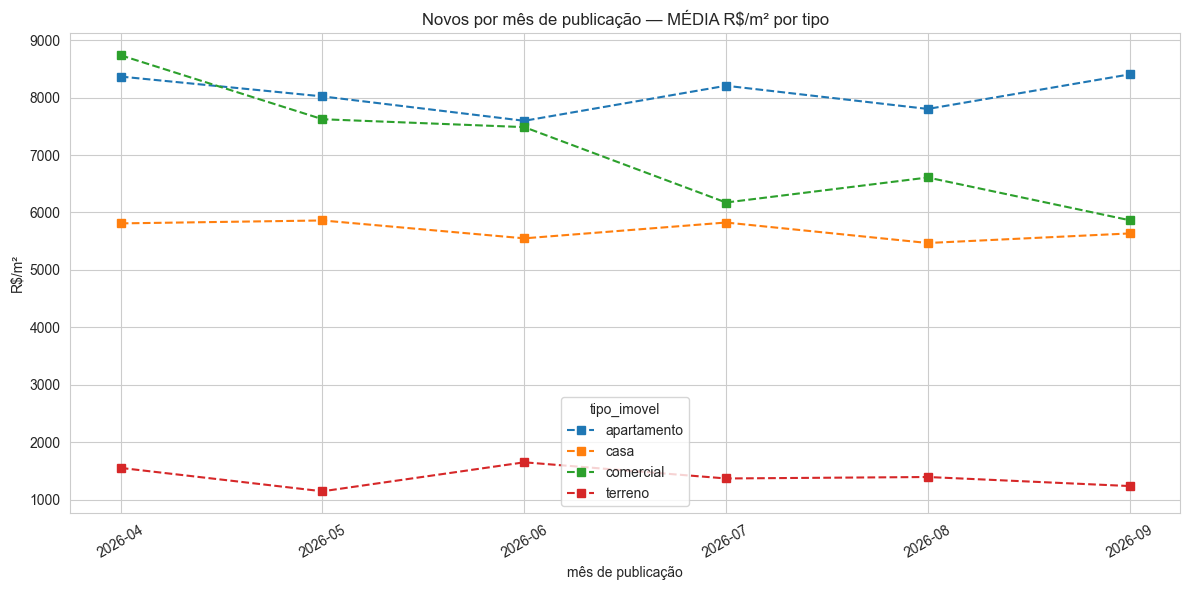

In [10]:
# Coorte por mês de publicação x tipo de imóvel (mediana e média de R$/m²)
TIPOS_COORTE = ["apartamento", "casa", "terreno", "comercial"]
RECORTE = ["2026-04", "2026-05", "2026-06", "2026-07", "2026-08", "2026-09"]

pub_r = pub[pub["mes_pub"].isin(RECORTE)]
ct = (pub_r[pub_r["tipo_imovel"].isin(TIPOS_COORTE)]
      .groupby(["mes_pub", "tipo_imovel"])["preco_por_m2"]
      .agg(["median", "mean", "size"]))
med_t = ct["median"].unstack("tipo_imovel")
mean_t = ct["mean"].unstack("tipo_imovel")
n_t = ct["size"].unstack("tipo_imovel")
med_t = med_t.where(n_t >= 20)
display(med_t.round(0))
display(n_t)

ax = med_t.plot(marker="o", figsize=(12, 6))
ax.set_title("Novos por mês de publicação — mediana R$/m² por tipo")
ax.set_xlabel("mês de publicação")
ax.set_ylabel("R$/m²")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

ax = mean_t.where(n_t >= 20).plot(marker="s", linestyle="--", figsize=(12, 6))
ax.set_title("Novos por mês de publicação — MÉDIA R$/m² por tipo")
ax.set_xlabel("mês de publicação")
ax.set_ylabel("R$/m²")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Top 12 bairros da coorte (mais caros): ['atiradores', 'america', 'centro', 'anita garibaldi', 'santo antonio', 'gloria', 'saguacu', 'bucarein', 'costa e silva', 'bom retiro', 'sao marcos', 'jardim sofia']


bairro,america,anita garibaldi,atiradores,bom retiro,bucarein,centro,costa e silva,gloria,jardim sofia,saguacu,santo antonio,sao marcos
mes_pub,,,,,,,,,,,,
2026-04,9692.0,8181.0,10085.0,5944.0,6910.0,9750.0,6139.0,7635.0,5676.0,7106.0,8400.0,5385.0
2026-05,9727.0,8639.0,8558.0,6653.0,6696.0,10092.0,6840.0,7118.0,NaN,6789.0,6356.0,NaN
2026-06,8333.0,7391.0,8693.0,5974.0,6739.0,8333.0,6461.0,6206.0,NaN,6836.0,6715.0,5638.0
2026-07,9934.0,8155.0,10000.0,6286.0,6266.0,9077.0,6528.0,7572.0,NaN,6970.0,7837.0,6000.0
2026-08,8598.0,7899.0,8570.0,6240.0,6720.0,9589.0,6375.0,6821.0,5915.0,7094.0,7316.0,5909.0
2026-09,9260.0,8140.0,9639.0,6235.0,7052.0,8837.0,5902.0,7258.0,NaN,7607.0,7555.0,5773.0


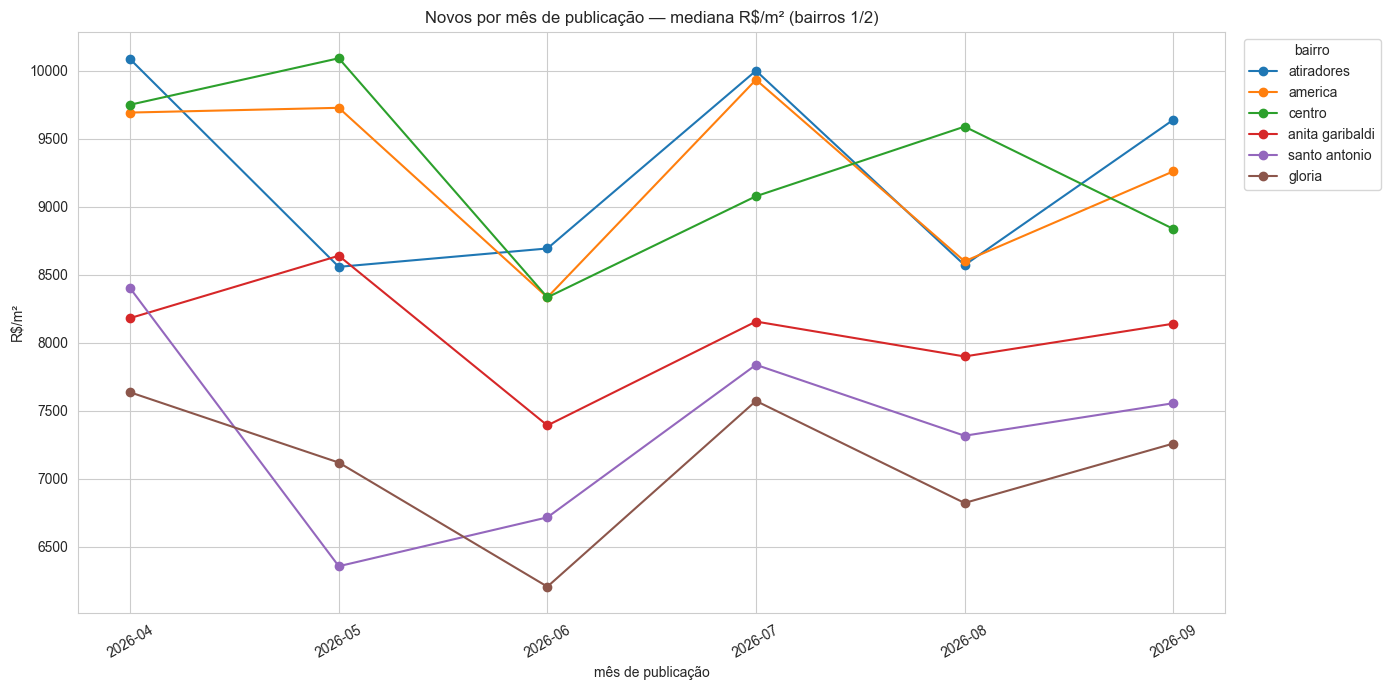

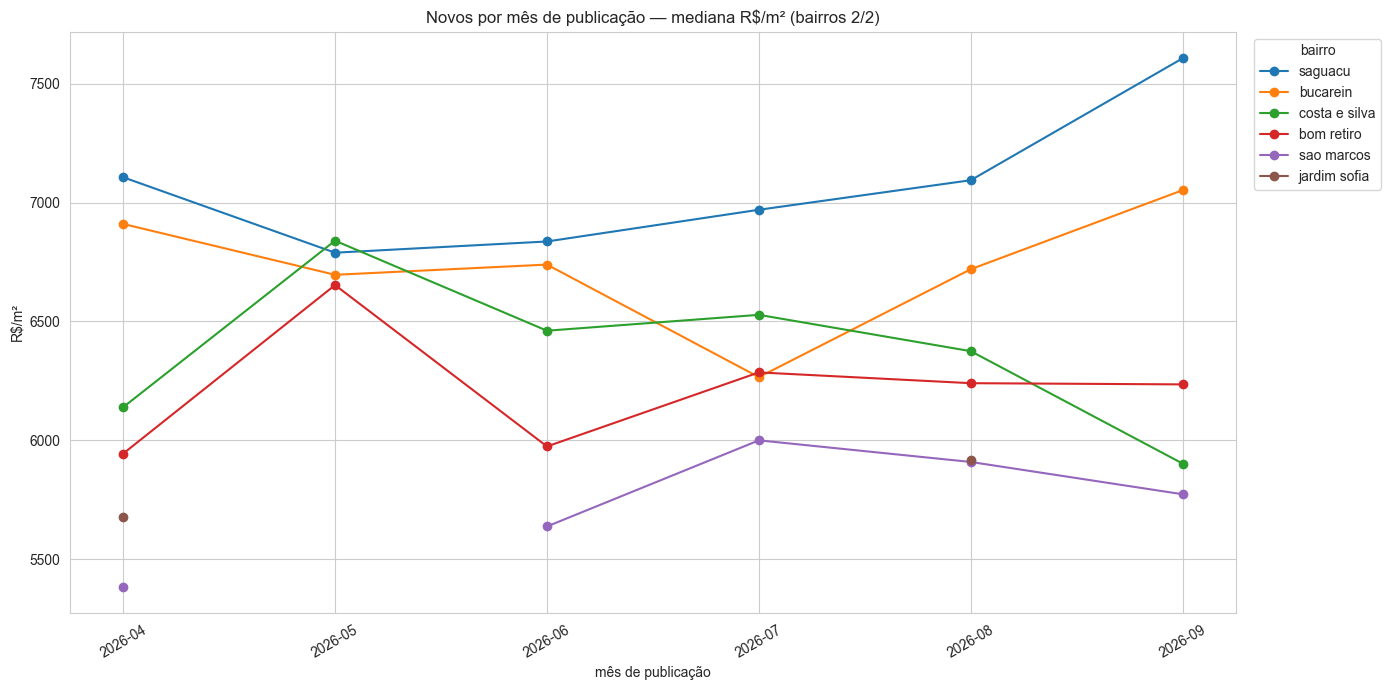

In [11]:
# Coorte por mês de publicação x bairro (top 12 por MEDIANA de m² na janela)
TOP_C = (pub_r[~pub_r["bairro"].str.lower().isin(LIXO)]
         .groupby("bairro")["preco_por_m2"].agg(["median", "count"]))
TOP_C = TOP_C[TOP_C["count"] >= 100].sort_values("median", ascending=False).head(12)
print("Top 12 bairros da coorte (mais caros):", list(TOP_C.index))
G1, G2 = TOP_C.index[:6].tolist(), TOP_C.index[6:].tolist()

cb = (pub_r[pub_r["bairro"].isin(TOP_C.index)]
      .groupby(["mes_pub", "bairro"])["preco_por_m2"]
      .agg(["median", "size"]))
med_b = cb["median"].unstack("bairro")
n_b = cb["size"].unstack("bairro")
med_b = med_b.where(n_b >= 20)
display(med_b.round(0))

for i, grupo in enumerate([G1, G2], start=1):
    ax = med_b[grupo].plot(marker="o", figsize=(14, 7))
    ax.set_title(f"Novos por mês de publicação — mediana R$/m² (bairros {i}/2)")
    ax.set_xlabel("mês de publicação")
    ax.set_ylabel("R$/m²")
    ax.legend(title="bairro", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

## 6. Oferta e giro (churn, tempo de mercado, reduções)

Dinâmica da oferta a partir do painel de URLs (URL sem query string como chave):
1. **churn** (entradas/saídas), 2. **tempo de mercado** (sobrevivência por coorte),
3. **reduções de preço** (mesmo anúncio, valor menor), 4. **absorção** por bairro.
Abr/26 é baseline (sem taxas). Limite do dado: republicação com id novo conta
como saída+entrada; URLs cobrem 100% das fontes, `dias_publicacao` só ~39%.

,mes,estoque,entradas,saidas,permanencia,tx_entrada_%,tx_saida_%
0,2026-04,33876,NaN,NaN,NaN,NaN,NaN
1,2026-05,26300,6077.0,13653.0,20223.0,23.1,40.3
2,2026-06,23756,8239.0,14743.0,11557.0,34.7,56.1
3,2026-07,22699,4572.0,9195.0,14561.0,20.1,38.7
4,2026-08,24744,8277.0,9351.0,13348.0,33.5,41.2
5,2026-09,23802,12210.0,14917.0,9827.0,51.3,60.3
6,2026-10,26361,12766.0,13172.0,10630.0,48.4,55.3


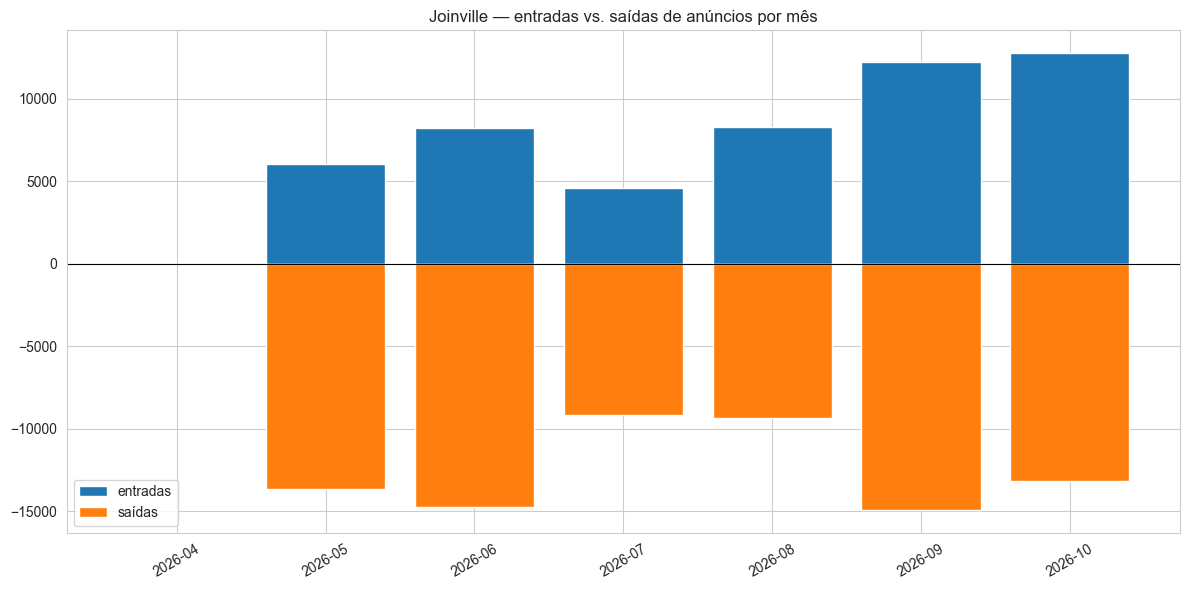

In [12]:
# 1. Churn: entradas, saídas e permanência por mês (a partir de mai/26)
b2 = base.copy()
b2["url_norm"] = b2["url"].str.split("?").str[0]
MESES = sorted(b2["mes"].unique())

# entradas = 1ª aparição (vs. tudo já visto); saídas/permanência = vs. mês anterior
churn, vistos, prev = [], set(), None
for mes in MESES:
    urls = set(b2.loc[b2["mes"] == mes, "url_norm"])
    if prev is None:
        churn.append({"mes": mes, "estoque": len(urls), "entradas": None,
                      "saidas": None, "permanencia": None})
    else:
        churn.append({"mes": mes, "estoque": len(urls), "entradas": len(urls - vistos),
                      "saidas": len(prev - urls), "permanencia": len(urls & prev)})
    vistos |= urls
    prev = urls

churn = pd.DataFrame(churn)
churn["tx_entrada_%"] = (churn["entradas"] / churn["estoque"] * 100).round(1)
churn["tx_saida_%"] = (churn["saidas"] / churn["estoque"].shift(1) * 100).round(1)
display(churn)

fig, ax = plt.subplots()
ax.bar(churn["mes"], churn["entradas"], label="entradas")
ax.bar(churn["mes"], -churn["saidas"].fillna(0), label="saídas")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Joinville — entradas vs. saídas de anúncios por mês")
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

,n,mediana,p75
mes,,,
2026-04,10183,123.0,370.0
2026-05,2837,144.0,452.0
2026-06,7616,150.0,390.0
2026-07,1652,124.0,320.0
2026-08,4835,152.0,368.0
2026-09,9745,154.0,433.0
2026-10,10262,162.0,413.0


,+0m,+1m,+2m,+3m,+4m,+5m,+6m
2026-04,1.0,0.597,0.428,0.334,0.308,0.159,0.162
2026-05,1.0,0.165,0.386,0.225,0.160,0.115,NaN
2026-06,1.0,0.541,0.373,0.186,0.180,NaN,NaN
2026-07,1.0,0.347,0.194,0.189,NaN,NaN,NaN
2026-08,1.0,0.339,0.284,NaN,NaN,NaN,NaN
2026-09,1.0,0.222,NaN,NaN,NaN,NaN,NaN
2026-10,1.0,NaN,NaN,NaN,NaN,NaN,NaN


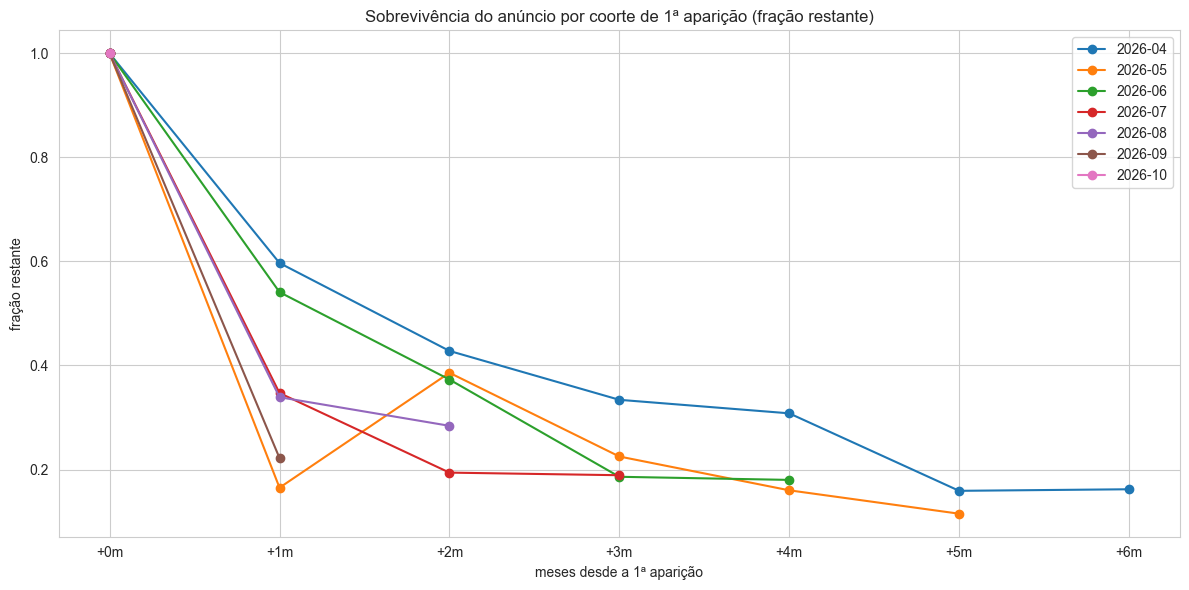

In [13]:
# 2a. dias_publicacao (só zap/vivareal/imovelweb) — mediana e P75 por mês
dp = base.dropna(subset=["dias_publicacao"]).groupby("mes")["dias_publicacao"]
dp_tab = pd.DataFrame({"n": dp.size(), "mediana": dp.median(),
                       "p75": dp.quantile(0.75)}).round(0)
display(dp_tab)

# 2b. Sobrevivência: coorte = mês da 1ª aparição no painel (100% das URLs);
# fração da coorte ainda presente k meses depois (k=0 é 1.0 por construção)
pres = (b2[["url_norm", "mes"]].drop_duplicates().assign(v=1)
        .pivot_table(index="url_norm", columns="mes", values="v", fill_value=0))
pres = pres.reindex(columns=MESES, fill_value=0)
coorte0 = pres.idxmax(axis=1).rename("coorte")
al = pres.join(coorte0)
curvas = {}
for c in MESES:
    g = al[al["coorte"] == c]
    if len(g) == 0:
        continue
    i0 = MESES.index(c)
    curvas[c] = {k: round(float(g[MESES[i0 + k]].mean()), 3)
                 for k in range(len(MESES) - i0)}
curva = pd.DataFrame(curvas).T
curva.columns = [f"+{k}m" for k in curva.columns]
display(curva)
ax = curva.T.plot(marker="o", figsize=(12, 6))
ax.set_title("Sobrevivência do anúncio por coorte de 1ª aparição (fração restante)")
ax.set_xlabel("meses desde a 1ª aparição")
ax.set_ylabel("fração restante")
plt.tight_layout()
plt.show()

In [14]:
# 3. Reduções: mesmo anúncio em M-1 e M com valor menor (variação < -1%)
px = (b2[["url_norm", "mes", "valor_imovel", "bairro", "tipo_imovel"]]
      .sort_values(["url_norm", "mes"]))
px["valor_ant"] = px.groupby("url_norm")["valor_imovel"].shift(1)
px["mes_ant"] = px.groupby("url_norm")["mes"].shift(1)
red = px[(px["valor_ant"].notna()) & (px["valor_imovel"] < px["valor_ant"] * 0.99)].copy()
red["desconto_%"] = ((red["valor_imovel"] - red["valor_ant"]) / red["valor_ant"] * 100).round(1)
red = red[red["desconto_%"] > -50]  # quedas >50%: fora da leitura (outlier/erro)

base_n = px.groupby("mes")["url_norm"].nunique()
ced = (red.groupby("mes").agg(n_cederam=("url_norm", "nunique"),
                                 desconto_med=("desconto_%", "median"))
       .join(base_n.rename("n_painel")))
ced["pct_cederam_%"] = (ced["n_cederam"] / ced["n_painel"] * 100).round(2)
display(ced)
print("Maiores descontos medianos por bairro:")
display(red.groupby("bairro")["desconto_%"].agg(["count", "median"])
        .sort_values("median").head(12).round(1))

# 4. Absorção por bairro: saídas ÷ estoque (média dos últimos 3 meses)
sets = b2[b2["mes"].isin(MESES[-4:])].groupby(["mes", "bairro"])["url_norm"].apply(set)
rows = []
for mes in MESES[-3:]:
    ant = MESES[MESES.index(mes) - 1]
    for bairro in sets.loc[mes].index:
        est = len(sets.loc[(mes, bairro)])
        ant_set = sets.get((ant, bairro), set())
        sai = len(ant_set - sets.loc[(mes, bairro)])
        rows.append({"mes": mes, "bairro": bairro, "estoque": est, "saidas": sai})
abs_b = pd.DataFrame(rows)
abs_b["absorcao_%"] = (abs_b["saidas"] / abs_b.groupby("bairro")["estoque"]
                       .transform("mean") * 100).round(1)
display(abs_b.groupby("bairro")["absorcao_%"].mean()
        .sort_values(ascending=False).head(15).rename("absorcao_media_%"))

,n_cederam,desconto_med,n_painel,pct_cederam_%
mes,,,,
2026-05,28,-5.65,26300,0.11
2026-06,369,-6.00,23756,1.55
2026-07,136,-5.70,22699,0.60
2026-08,260,-5.50,24744,1.05
2026-09,145,-6.10,23802,0.61
2026-10,126,-5.65,26361,0.48


Maiores descontos medianos por bairro:


,count,median
bairro,,
fatima,1,-13.5
ulysses guimaraes,1,-11.8
santa catarina,4,-11.0
pirabeiraba,9,-9.5
distrito industrial,2,-8.6
morro do meio,1,-7.8
ulisses guimaraes,1,-7.5
parque guarani,9,-7.4
itaum,7,-7.2


bairro
s/b               700.000000
vila cubatao       77.766667
fatima             61.066667
jardim paraiso     60.066667
boehmerwald        59.366667
paranaguamirim     59.333333
jarivatuba         58.900000
santa catarina     58.600000
petropolis         58.133333
adhemar garcia     57.966667
nova brasilia      57.566667
guanabara          57.500000
joao costa         54.866667
boa vista          54.600000
floresta           54.466667
Name: absorcao_media_%, dtype: float64

## 7. Resumo

_Preencher após execução: variação geral no período, tipos e bairros que mais valorizaram/desvalorizaram, e se a oferta nova entra acima ou abaixo do estoque._

# Verificando o urls que existiam no mes anterior

In [15]:
import pandas as pd
from collections import Counter

#df = pd.read_json('olx_alugueis.json', lines=True)
import pandas as pd
from pathlib import Path


cidade = 'joinville'

estado = 'sc'

BASE_DIR = Path.cwd().parent
PASTA_DADOS = BASE_DIR / 'dados' / cidade

df_04 = pd.read_parquet(f'{PASTA_DADOS}/{cidade}_imoveis_limpo_2026-04.parquet')
df_05 = pd.read_parquet(f'{PASTA_DADOS}/{cidade}_imoveis_limpo_2026-05.parquet')
df_06 = pd.read_parquet(f'{PASTA_DADOS}/{cidade}_imoveis_limpo_2026-06.parquet')
df_07 = pd.read_parquet(f'{PASTA_DADOS}/{cidade}_imoveis_limpo_2026-07.parquet')
df_08 = pd.read_parquet(f'{PASTA_DADOS}/{cidade}_imoveis_limpo_2026-08.parquet')
df_09 = pd.read_parquet(f'{PASTA_DADOS}/{cidade}_imoveis_limpo_2026-09.parquet')
df_10 = pd.read_parquet(f'{PASTA_DADOS}/{cidade}_imoveis_limpo_2026-10.parquet')

# --- Tamanho por mes ---
print('=== Registros por mes ===')
for i, df in enumerate([df_04, df_05, df_06, df_07, df_08, df_09, df_10], 4):
    print(f'  {i:02d}/2026: {len(df):>6} registros, {df.shape[1]} colunas')

# --- URLs por mes ---
urls = {}
for m, df in [(4, df_04), (5, df_05), (6, df_06), (7, df_07), (8, df_08), (9, df_09), (10, df_10)]:
    urls[m] = set(df['url'].dropna())

# --- Intersecao com setembro ---
print('\n=== Intersecao com outubro (10) ===')
for m in [4, 5, 6, 7, 8, 9, 10]:
    inter = urls[m] & urls[10]
    so_antigo = urls[m] - urls[10]
    so_10 = urls[10] - urls[m]
    print(f'  {m:02d} vs 10: ambos={len(inter)}, so_no_{m:02d}={len(so_antigo)}, so_no_10={len(so_10)}')

# --- Novos e removidos por transicao ---
print('\n=== Novos por mes (nao existiam no mes anterior) ===')
for m in [5, 6, 7, 8, 9, 10]:
    novos = urls[m] - urls[m - 1]
    print(f'  Novos em {m:02d}: {len(novos)}')

print('\n=== Removidos por mes (existiam no anterior) ===')
for m in [5, 6, 7, 8, 9, 10]:
    removidos = urls[m - 1] - urls[m]
    print(f'  Removidos do {m - 1:02d} para {m:02d}: {len(removidos)}')

# --- Persistencia ---
todas_urls = []
for m in [4, 5, 6, 7, 8, 9, 10]:
    todas_urls.extend(urls[m])

contagem = Counter(todas_urls)
persistencia = Counter(contagem.values())

print('\n=== Persistencia (em quantos meses cada URL aparece) ===')
for meses, qtd in sorted(persistencia.items()):
    print(f'  {meses} meses: {qtd} URLs')



=== Registros por mes ===
  04/2026:  34573 registros, 33 colunas
  05/2026:  26905 registros, 33 colunas
  06/2026:  24336 registros, 62 colunas
  07/2026:  23152 registros, 62 colunas
  08/2026:  25312 registros, 32 colunas
  09/2026:  24235 registros, 83 colunas
  10/2026:  26912 registros, 69 colunas

=== Intersecao com outubro (10) ===
  04 vs 10: ambos=5557, so_no_04=29016, so_no_10=21355
  05 vs 10: ambos=6117, so_no_05=20788, so_no_10=20795
  06 vs 10: ambos=6533, so_no_06=17803, so_no_10=20379
  07 vs 10: ambos=8144, so_no_07=15008, so_no_10=18768
  08 vs 10: ambos=8770, so_no_08=16542, so_no_10=18142
  09 vs 10: ambos=9752, so_no_09=14483, so_no_10=17160
  10 vs 10: ambos=26912, so_no_10=0, so_no_10=0

=== Novos por mes (nao existiam no mes anterior) ===
  Novos em 05: 6201
  Novos em 06: 12506
  Novos em 07: 8275
  Novos em 08: 11697
  Novos em 09: 15394
  Novos em 10: 17160

=== Removidos por mes (existiam no anterior) ===
  Removidos do 04 para 05: 13869
  Removidos do 05 

In [16]:
df_10['lat'].value_counts()

lat
-26.290361    1861
-26.318420    1336
-24.285792    1182
-26.286313    1131
-21.693883     995
              ... 
-26.333136       1
-26.279650       1
-26.272200       1
-26.338871       1
-26.265188       1
Name: count, Length: 2630, dtype: int64

In [17]:
df_09.shape

(24235, 83)

In [18]:
urls_comuns = urls[4] & urls[5] & urls[6] & urls[7] & urls[8] & urls[9] & urls[10]

df_filtrado = df_10[df_10['url'].isin(urls_comuns)]

print(f'URLs presentes em todos os 7 meses: {len(urls_comuns)}')
print(f'Registros em df_10 filtrados: {len(df_filtrado)}')

URLs presentes em todos os 7 meses: 3261
Registros em df_10 filtrados: 3261


In [19]:
df_filtrado[df_filtrado['tipo_imovel'].isin(['apartamento'])]['url'].to_dict()

{8978: 'https://www.chavesnamao.com.br/imovel/apartamento-a-venda-2-quartos-com-garagem-sc-joinville-fatima-68m2-RS279600/id-39748088/',
 8988: 'https://www.chavesnamao.com.br/imovel/apartamento-a-venda-2-quartos-com-garagem-sc-joinville-floresta-89m2-RS370000/id-39618149/',
 8992: 'https://www.chavesnamao.com.br/imovel/apartamento-a-venda-2-quartos-com-garagem-sc-joinville-fatima-116m2-RS264500/id-35154697/',
 8994: 'https://www.chavesnamao.com.br/imovel/apartamento-a-venda-1-quarto-sc-joinville-atiradores-65m2-RS398000/id-40772703/',
 8998: 'https://www.chavesnamao.com.br/imovel/apartamento-a-venda-2-quartos-com-garagem-sc-joinville-vila-nova-RS261450/id-39618615/',
 8999: 'https://www.chavesnamao.com.br/imovel/apartamento-a-venda-2-quartos-com-garagem-sc-joinville-anita-garibaldi-RS486450/id-25122852/',
 9002: 'https://www.chavesnamao.com.br/imovel/apartamento-a-venda-1-quarto-sc-joinville-anita-garibaldi-32m2-RS360000/id-32981384/',
 9011: 'https://www.chavesnamao.com.br/imovel/apa

In [20]:
df_filtrado.groupby(['bairro', 'tipo_imovel'])['preco_por_m2'].aggregate(['mean', 'median','count']).head(50)

mean        median  count
bairro              tipo_imovel                                   
adhemar garcia      apartamento  5.092584e+03   5283.018868      7
                    casa         4.830496e+03   4607.843137     13
america             apartamento  1.033758e+04  10563.246696    371
                    casa         8.690051e+03   8389.830508     63
                    comercial    9.196367e+03   9248.182919      6
                    terreno      6.584261e+03   6984.924623      3
anita garibaldi     apartamento  9.086174e+03   9243.920685    272
                    casa         8.000764e+03   7068.965517     69
                    comercial    8.904412e+03   8904.411765      1
area rural          rural        6.758824e+03   6758.823529      1
atiradores          apartamento  1.063301e+04  10615.500000    149
                    casa         8.525177e+03   8066.302910     18
                    comercial    1.890666e+04  23672.489796      3
                    terreno      1.190476e+04  11904.761905      1
aventureiro         apartamento  5.674582e+03   5390.625000     13
                    casa         5.668179e+03   5437.352246     32
boa vista           apartamento  5.668412e+03   5467.741935      7
                    casa         6.685092e+03   5813.953488     45
                    comercial    6.557377e+03   6557.377049      1
boehmerwald         apartamento  5.485425e+03   5909.090909      5
                    casa         4.481668e+03   4297.619048     18
bom retiro          apartamento  7.464616e+03   7100.331675     60
                    casa         6.612187e+03   6222.015837     88
                    comercial    5.106383e+03   5106.382979      1
bucarein            apartamento  7.780735e+03   7195.474505     36
                    casa         6.284621e+03   6325.718242     20
                    comercial    7.812500e+03   7812.500000      1
centro              apartamento  1.000698e+04  10344.827586    117
                    casa         7.843723e+03   6969.696970      5
                    comercial    7.058477e+03   6250.000000     15
comasa              apartamento  5.671046e+03   6163.461538      3
                    casa         5.106936e+03   4943.243243     22
costa e silva       apartamento           inf   7263.964929    168
                    casa                  inf   5801.958166    108
                    comercial    7.926501e+03   7379.912664      3
                    terreno      8.771930e+03   8771.929825      1
distrito industrial apartamento  6.200993e+03   6200.992949      2
                    casa         6.265238e+03   6265.238095      2
espinheiros         apartamento  7.091591e+03   6865.384615      5
                    casa         4.828033e+03   4848.450057     18
                    terreno      1.624103e+03   1650.000000      3
fatima              apartamento  6.397027e+03   6082.463768      8
                    casa         3.974078e+03   4538.461538      7
                    terreno      6.190476e+03   6190.476190      1
floresta            apartamento  7.065961e+03   7167.515660     36
                    casa         5.803588e+03   5548.872180     92
                    terreno      1.443001e+03   1443.001443      1
gloria              apartamento  9.443243e+03   8775.601644     90
                    casa         8.262091e+03   7807.017544    119
                    comercial    1.198466e+04  11984.659636      1

In [21]:
import pandas as pd
import numpy as np

# --- Filtrar URLs presentes em todos os 6 meses ---
urls_comuns = urls[4] & urls[5] & urls[6] & urls[7] & urls[8] & urls[9]
df_filtrado = df_09[df_09['url'].isin(urls_comuns)].copy()

print(f'URLs presentes em todos os 6 meses: {len(urls_comuns)}')
print(f'Registros em df_09 filtrados: {len(df_filtrado)}')
print()

# --- 1. Visao geral por tipo ---
print('=== Distribuicao por tipo de imovel ===')
tipo_resumo = df_filtrado.groupby('tipo_imovel').agg(
    qtd=('url', 'count'),
    preco_m2_medio=('preco_por_m2', 'mean'),
    preco_m2_mediana=('preco_por_m2', 'median'),
    metragem_media=('metragem', 'mean'),
    valor_medio=('valor_imovel', 'mean'),
).round(0)
print(tipo_resumo.to_string())
print()

# --- 2. Top bairros por preco m2 ---
print('=== Top 15 bairros por preco m2 medio ===')
bairro_resumo = df_filtrado.groupby('bairro').agg(
    qtd=('url', 'count'),
    preco_m2_medio=('preco_por_m2', 'mean'),
    preco_m2_mediana=('preco_por_m2', 'median'),
    metragem_media=('metragem', 'mean'),
    valor_medio=('valor_imovel', 'mean'),
).round(0)
bairro_resumo = bairro_resumo[bairro_resumo['qtd'] >= 5].sort_values('preco_m2_medio', ascending=False)
print(bairro_resumo.head(15).to_string())
print()

# --- 3. Cruzamento bairro x tipo (preco m2 medio) ---
print('=== Preco m2 medio: bairro x tipo (top 30) ===')
cruzado = df_filtrado.groupby(['bairro', 'tipo_imovel']).agg(
    qtd=('url', 'count'),
    preco_m2_medio=('preco_por_m2', 'mean'),
    preco_m2_mediana=('preco_por_m2', 'median'),
).round(0)
cruzado = cruzado[cruzado['qtd'] >= 3].sort_values('preco_m2_medio', ascending=False)
print(cruzado.head(30).to_string())
print()

# --- 4. Faixas de preco por bairro ---
print('=== Distribuicao por faixa de preco por bairro (top 10 bairros) ===')
top_bairros = df_filtrado['bairro'].value_counts().head(10).index
faixa_bairro = df_filtrado[df_filtrado['bairro'].isin(top_bairros)].groupby(['bairro', 'faixa']).size().unstack(fill_value=0)
print(faixa_bairro.to_string())
print()

# --- 5. Metricas por quartos ---
print('=== Preco m2 por quantidade de quartos ===')
quartos_resumo = df_filtrado.groupby('quartos').agg(
    qtd=('url', 'count'),
    preco_m2_medio=('preco_por_m2', 'mean'),
    preco_m2_mediana=('preco_por_m2', 'median'),
    metragem_media=('metragem', 'mean'),
    valor_medio=('valor_imovel', 'mean'),
).round(0)
print(quartos_resumo.to_string())
print()

# --- 6. Fonte dos dados ---
print('=== Distribuicao por fonte ===')
print(df_filtrado['fonte'].value_counts().to_string())

URLs presentes em todos os 6 meses: 3917
Registros em df_09 filtrados: 3917

=== Distribuicao por tipo de imovel ===
                 qtd  preco_m2_medio  preco_m2_mediana  metragem_media  valor_medio
tipo_imovel                                                                        
apartamento     2159             inf            8629.0           106.0     969671.0
casa            1670             inf            6000.0           140.0     879145.0
comercial         42          8480.0            7653.0            96.0     791233.0
galpao             4          4441.0            3954.0           198.0     851250.0
outros             1          7755.0            7755.0            49.0     380000.0
predio_inteiro     1          7500.0            7500.0           200.0    1500000.0
rural             12         26420.0           11667.0           152.0    2640833.0
terreno           28          4630.0            3199.0          5232.0    1293941.0

=== Top 15 bairros por preco m2 medio ===
